In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd
from scipy import stats

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

In [15]:
engagement_type_data = df[["Login_Frequency", "Pages_Per_Session","Session_Duration_Avg", "Mobile_App_Usage", "Social_Media_Engagement_Score"]]

In [16]:
stats = engagement_type_data.describe().T  # .T = transpose ให้อ่านง่ายขึ้น
stats["skewness"] = engagement_type_data.skew()
stats["kurtosis"] = engagement_type_data.kurt()
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Login_Frequency,50000.0,11.624660,7.810657,0.0,6.0,11.0,17.0,46.0,0.511945,-0.144381
Pages_Per_Session,50000.0,8.717542,3.663996,1.0,6.2,8.4,11.0,24.1,0.419215,0.074851
Session_Duration_Avg,50000.0,27.602240,10.497234,1.0,20.2,26.8,34.0,75.6,0.431393,0.133731
Mobile_App_Usage,50000.0,19.294446,8.938875,0.0,13.2,18.6,24.6,61.9,0.452248,0.239742
Social_Media_Engagement_Score,50000.0,29.152730,19.308632,0.0,15.3,27.6,40.7,100.0,0.570295,0.150854


### 1) Login Frequency

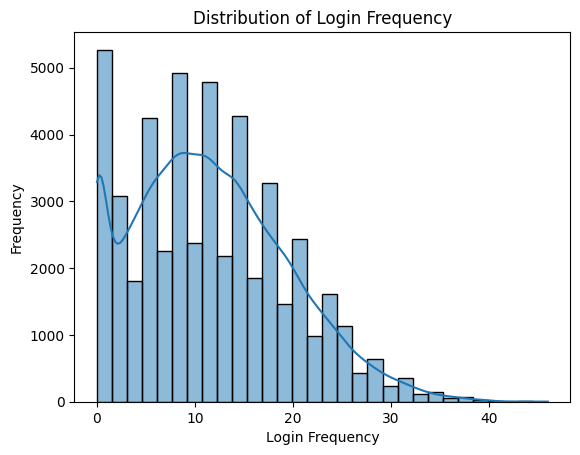

In [17]:
sns.histplot(df["Login_Frequency"], bins=30, kde=True)
plt.title("Distribution of Login Frequency")
plt.xlabel("Login Frequency")
plt.ylabel("Frequency")
plt.show()

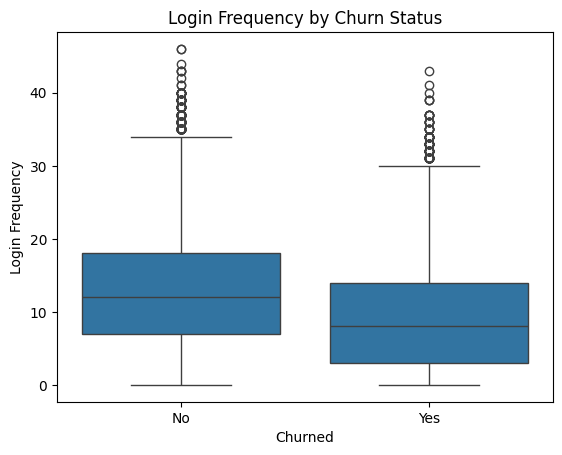

In [18]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Login_Frequency")
plt.title("Login Frequency by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Login Frequency")
plt.show()

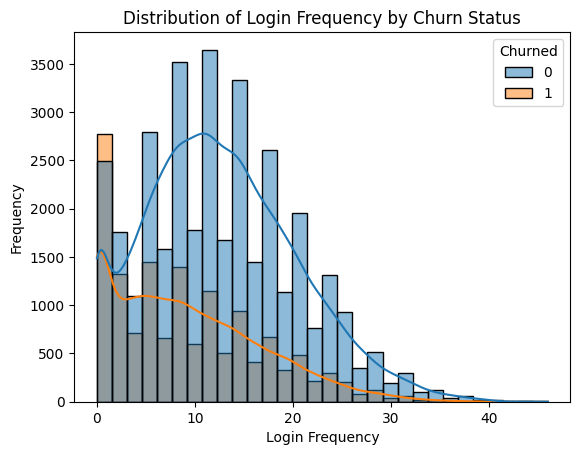

In [19]:
sns.histplot(data=df, x="Login_Frequency", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Login Frequency by Churn Status")
plt.xlabel("Login Frequency")
plt.ylabel("Frequency")
plt.show()

In [23]:

churned = df[df["Churned"] == 1]["Login_Frequency"]
not_churned = df[df["Churned"] == 0]["Login_Frequency"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญ")
else:
    print("ไม่มีความแตกต่าง")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญ


In [24]:
Q1 = df["Login_Frequency"].quantile(0.25)
Q3 = df["Login_Frequency"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Login_Frequency"] < Q1 - 1.5 * IQR) | 
              (df["Login_Frequency"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 309 rows (0.62%)


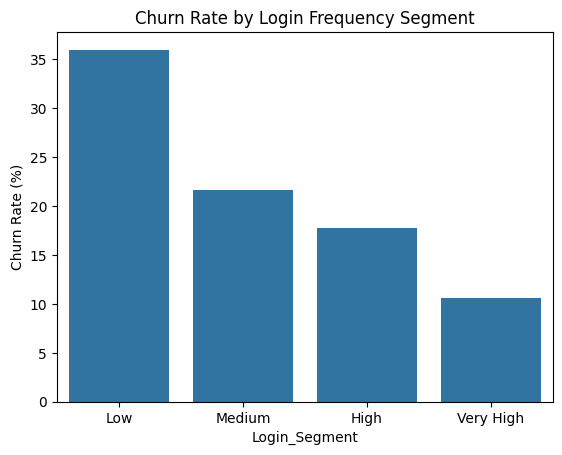

In [25]:
df["Login_Segment"] = pd.cut(df["Login_Frequency"], 
                              bins=4, 
                              labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Login_Segment")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Login Frequency Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

### 2) Pages_Per_Session